<a href="https://colab.research.google.com/github/Lexuanthangutc/Cell-Detection/blob/main/PSPNET_Cell_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip3 install -q torchmetrics
!pip3 install -q segmentation-models-pytorch
!pip3 install -q albumentations

# Connect Google Drive

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# Packages

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageColor
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchmetrics
from torchmetrics import Dice, JaccardIndex
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2 # np.array -> torch.tensor


import os
from tqdm import tqdm
from glob import glob # read and close image in folder


19 Tissue types (Breast, Colon, Bile-duct, Esophagus, Uterus, Lung, Cervix, Head&Neck, Skin, Adrenal Gland, Kidney, Stomach, Prostate, Testis, Liver, Thyroid, Pancreas, Ovary, Bladder). Note, that it also unifies existing datasets within it, we have carefully labelled these under a single nuclei categories schema that is common to all 19 tissues.

**This particular directory includes training patches of size 256x256 and their masks, this is one of the folds. In total there are more than 7 thousand training patches within all of the three folds.**

The files within each fold directories are:

* `images.npy` - image patches of 256x256

* `masks.npy` an array of 6 channel instance-wise masks (0: Neoplastic cells, 1: Inflammatory, 2: Connective/Soft tissue cells, 3: Dead Cells, 4: Epithelial, 6: Background)

* `types.py`  tissue type that a given path was extracted from.

# Preprocessing

In [4]:
Data_dir = "/kaggle/input/cell-analysis"
images_dir = "/kaggle/input/cell-analysis/P01_images"
masks_dir = "/kaggle/input/cell-analysis/P01_masks"

CELL_CLASSES = [
    "Marcophage/Monocyte",
    "Neutrophil",
    "Eosinophil",
    "Lymphocyte",
    "Unknown cell/Debris",
    "Basophil",
]

trainsize = 257
train_transform = A.Compose([
    A.Resize(width=trainsize, height=trainsize),
    A.HorizontalFlip(),
    # A.RandomBrightnessContrast(),
    A.Blur(),
    A.Sharpen(),
    # A.RGBShift(),
    A.CoarseDropout(),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
    ToTensorV2(),
])

# Define color to class index mapping
label_colors = {
    (28, 230, 255): 1,  # Macrophage/Monocyte
    (255, 52, 255): 2,  # Neutrophil
    (255, 74, 70): 3,  # Eosinophil
    (0, 137, 65): 4,  # Lymphocyte
    (0, 111, 166): 5,  # Unknown cell/Debris
    (163, 0, 89): 6   # Basophil
}


# Dataset

In [5]:
class CellDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        """
        Args:
            images_dir (string): Path to the directory containing images.
            masks_dir (string): Path to the directory containing corresponding masks.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        """
        Return the total number of samples.
        """
        return len(self.images)

    def __getitem__(self, idx):
        """
        Generate one sample of data.
        """
        img_name = self.images[idx]
        mask_name = self.masks[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        image = np.array(image)
        mask = Image.open(mask_path).convert('RGB')

        # convert mask colors to classes
        mask = self.convert_mask(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image.float(), mask.long()

    def convert_mask(self, mask):
        """Convert RGB mask to a class map."""
        mask_array = np.array(mask)
        class_map = np.zeros(mask_array.shape[:2], dtype=np.int32)

        for color, class_id in label_colors.items():
            matches = (mask_array == color).all(axis=-1)
            class_map[matches] = class_id

        return class_map

In [6]:
# Initialize dataset
dataset = CellDataset(images_dir,masks_dir,transform=train_transform)

In [7]:
image,mask = dataset.__getitem__(1)

In [8]:
mask.shape

torch.Size([257, 257])

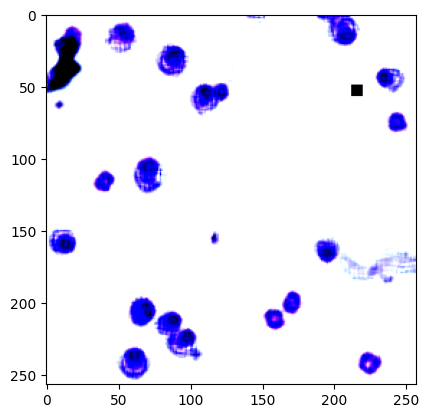

In [9]:
plt.imshow(image.permute(1,2,0).cpu())

In [10]:
mask.unique()

tensor([0, 1, 2, 4, 5])

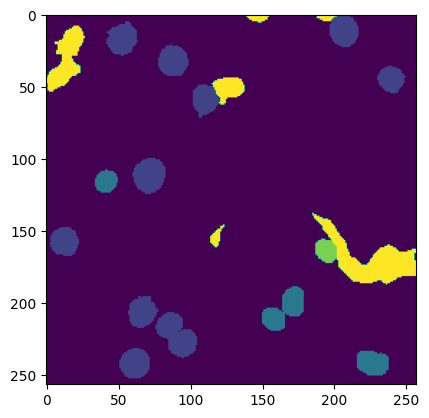

In [11]:
plt.imshow(mask.cpu())

In [12]:
def tensor_to_np(tensor):
    # Make sure the tensor is on the CPU and convert to NumPy
    return tensor.detach().cpu().numpy()

def np_to_tensor(array):
    # Convert a NumPy array back to PyTorch tensor
    return torch.tensor(array).float()

def inverse_norm(image):
    # Define the inverse transformation using Albumentations
    invTrans = A.Compose([
        A.Normalize(mean=[0., 0., 0.], std=[1/0.229, 1/0.224, 1/0.225], max_pixel_value=1.0),
        A.Normalize(mean=[-0.485, -0.456, -0.406], std=[1., 1., 1.], max_pixel_value=1.0),
    ])

    # Example usage:
    # Assuming 'tensor_image' is your normalized image tensor
    tensor_image_np = tensor_to_np(image)  # Convert tensor to numpy array
    tensor_image_np = np.transpose(tensor_image_np, (1, 2, 0))  # CHW to HWC for Albumentations

    # Apply the inverse transformation
    inv_img_np = invTrans(image=tensor_image_np)['image']
    inv_img_np = np.transpose(inv_img_np, (2, 0, 1))  # HWC back to CHW for PyTorch

    # Convert back to tensor
    inv_img_tensor = np_to_tensor(inv_img_np)
    return inv_img_tensor


torch.Size([3, 257, 257]) torch.Size([257, 257])
tensor([0, 1, 2, 3, 5])
tensor([[[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 6.9020e-01,
          9.3333e-01, 8.2353e-01],
         [1.0000e+00, 5.7255e-01, 7.0196e-01,  ..., 8.8235e-01,
          9.2941e-01, 5.9608e-01],
         [1.0000e+00, 1.7255e-01, 3.4902e-01,  ..., 8.5098e-01,
          9.0980e-01, 8.8235e-01],
         ...,
         [3.8431e-01, 3.8431e-01, 3.2941e-01,  ..., 8.7843e-01,
          8.6667e-01, 8.3137e-01],
         [2.3922e-01, 9.8039e-02, 1.5686e-01,  ..., 8.2745e-01,
          8.5882e-01, 8.5098e-01],
         [3.8431e-01, 3.1373e-01, 6.5490e-01,  ..., 8.5098e-01,
          8.9412e-01, 8.8235e-01]],

        [[1.0000e+00, 1.0000e+00, 1.0000e+00,  ..., 7.0980e-01,
          8.9412e-01, 8.3529e-01],
         [1.0000e+00, 5.1765e-01, 5.9608e-01,  ..., 8.3137e-01,
          8.9020e-01, 6.0784e-01],
         [1.0000e+00, 1.0980e-01, 3.2941e-01,  ..., 8.1569e-01,
          8.8627e-01, 8.5882e-01],
         ...,
      

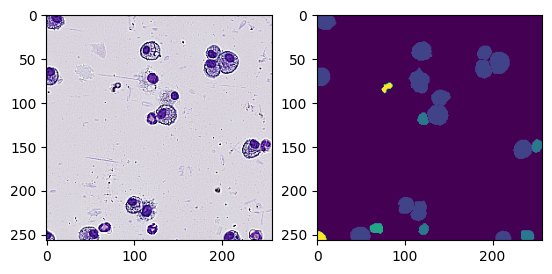

In [13]:
train_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)
image, mask = train_dataset.__getitem__(10)

print(image.shape, mask.shape)
print(mask.unique())
inv_img_tensor = inverse_norm(image)
print(inv_img_tensor)
plt.subplot(1,2,1)
plt.imshow(inv_img_tensor.permute(1,2,0))
plt.subplot(1,2,2)
plt.imshow(mask)
plt.show()

In [14]:
# # get pretrained model , get res50 model
!wget -O resnet50_v2.pth  "https://drive.google.com/uc?export=download&id=1w5pRmLJXvmQQA5PtCbHhZc_uC4o0YbmA"

--2024-09-06 11:01:20--  https://drive.google.com/uc?export=download&id=1w5pRmLJXvmQQA5PtCbHhZc_uC4o0YbmA
Resolving drive.google.com (drive.google.com)... 74.125.195.102, 74.125.195.101, 74.125.195.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.195.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1w5pRmLJXvmQQA5PtCbHhZc_uC4o0YbmA&export=download [following]
--2024-09-06 11:01:20--  https://drive.usercontent.google.com/download?id=1w5pRmLJXvmQQA5PtCbHhZc_uC4o0YbmA&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.197.132, 2607:f8b0:400e:c03::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.197.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102976423 (98M) [application/octet-stream]
Saving to: 'resnet50_v2.pth'

resnet50_v2.pth     100%[===================>]  98.21M   110MB

# Model

## Res50

In [15]:
def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)

class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, deep_base=True):
        super(ResNet, self).__init__()
        self.deep_base = deep_base
        if not self.deep_base:
            self.inplanes = 64
            self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
            self.bn1 = nn.BatchNorm2d(64)
        else:
            self.inplanes = 128
            self.conv1 = conv3x3(3, 64, stride=2)
            self.bn1 = nn.BatchNorm2d(64)
            self.conv2 = conv3x3(64, 64)
            self.bn2 = nn.BatchNorm2d(64)
            self.conv3 = conv3x3(64, 128)
            self.bn3 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AvgPool2d(7, stride=1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        if self.deep_base:
            x = self.relu(self.bn2(self.conv2(x)))
            x = self.relu(self.bn3(self.conv3(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out

In [16]:
def resnet50(pretrained=False, **kwargs):
    """Constructs a ResNet-50 model.

    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
    """
    model = ResNet(Bottleneck, [3, 4, 6, 3], **kwargs)
    if pretrained:
        # model.load_state_dict(model_zoo.load_url(model_urls['resnet50']))
        model_path = '/kaggle/working/resnet50_v2.pth'
        model.load_state_dict(torch.load(model_path), strict=False)
    return model


## PSPNet

In [17]:

class PPM(nn.Module):
    def __init__(self, in_dim, reduction_dim, bins):
        super(PPM, self).__init__()
        self.features = []
        for bin in bins:
            self.features.append(nn.Sequential(
                nn.AdaptiveAvgPool2d(bin),
                nn.Conv2d(in_dim, reduction_dim, kernel_size=1, bias=False),
                nn.BatchNorm2d(reduction_dim),
                nn.ReLU(inplace=True)
            ))
        self.features = nn.ModuleList(self.features)

    def forward(self, x):
        x_size = x.size()
        out = [x]
        for f in self.features:
            out.append(F.interpolate(f(x), x_size[2:], mode='bilinear', align_corners=True))
        return torch.cat(out, 1)

class PSPNet(nn.Module):
    def __init__(self, layers=50, bins=(1, 2, 3, 6), dropout=0.1, classes=2, zoom_factor=8, use_ppm=True, criterion=nn.CrossEntropyLoss(ignore_index=255), pretrained=True):
        super(PSPNet, self).__init__()
        assert layers in [50, 101, 152]
        assert 2048 % len(bins) == 0
        assert classes > 1
        assert zoom_factor in [1, 2, 4, 8]
        self.zoom_factor = zoom_factor
        self.use_ppm = use_ppm
        self.criterion = criterion

        if layers == 50:
            resnet = resnet50(pretrained=pretrained)
        # elif layers == 101:
        #     resnet = resnet101(pretrained=pretrained)
        # else:
        #     resnet = resnet152(pretrained=pretrained)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.conv2, resnet.bn2, resnet.relu, resnet.conv3, resnet.bn3, resnet.relu, resnet.maxpool)
        self.layer1, self.layer2, self.layer3, self.layer4 = resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4

        for n, m in self.layer3.named_modules():
            if 'conv2' in n:
                m.dilation, m.padding, m.stride = (2, 2), (2, 2), (1, 1)
            elif 'downsample.0' in n:
                m.stride = (1, 1)
        for n, m in self.layer4.named_modules():
            if 'conv2' in n:
                m.dilation, m.padding, m.stride = (4, 4), (4, 4), (1, 1)
            elif 'downsample.0' in n:
                m.stride = (1, 1)

        fea_dim = 2048
        if use_ppm:
            self.ppm = PPM(fea_dim, int(fea_dim/len(bins)), bins)
            fea_dim *= 2
        self.cls = nn.Sequential(
            nn.Conv2d(fea_dim, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(512, classes, kernel_size=1)
        )
        if self.training:
            self.aux = nn.Sequential(
                nn.Conv2d(1024, 256, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
                nn.Conv2d(256, classes, kernel_size=1)
            )

    def forward(self, x, y=None):
        x_size = x.size()
        assert (x_size[2]-1) % 8 == 0 and (x_size[3]-1) % 8 == 0
        h = int((x_size[2] - 1) / 8 * self.zoom_factor + 1)
        w = int((x_size[3] - 1) / 8 * self.zoom_factor + 1)

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x_tmp = self.layer3(x)
        x = self.layer4(x_tmp)
        if self.use_ppm:
            x = self.ppm(x)
        x = self.cls(x)
        if self.zoom_factor != 1:
            x = F.interpolate(x, size=(h, w), mode='bilinear', align_corners=True)

        if self.training:
            aux = self.aux(x_tmp)
            if self.zoom_factor != 1:
                aux = F.interpolate(aux, size=(h, w), mode='bilinear', align_corners=True)
            main_loss = self.criterion(x, y)
            aux_loss = self.criterion(aux, y)
            return x.max(1)[1], main_loss, aux_loss
        else:
            return x

In [18]:
BATCH_SIZE = 4
n_workers = 4
train_dataset = CellDataset(images_dir,masks_dir,transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers = n_workers)

In [19]:
train_loader.dataset[1][0]

tensor([[[1.7865, 1.7694, 1.7694,  ..., 1.7694, 1.7694, 1.7694],
         [1.7865, 1.7694, 1.7694,  ..., 1.7694, 1.7694, 1.7694],
         [1.7694, 1.7694, 1.7523,  ..., 1.7694, 1.7694, 1.7694],
         ...,
         [1.7865, 1.7865, 1.7865,  ..., 1.7694, 1.7865, 1.7694],
         [1.7865, 1.7694, 1.7694,  ..., 1.7865, 1.7865, 1.7694],
         [1.7865, 1.7865, 1.7865,  ..., 1.7694, 1.7865, 1.7694]],

        [[1.8158, 1.8158, 1.8158,  ..., 1.8333, 1.8333, 1.8333],
         [1.8158, 1.8158, 1.8158,  ..., 1.8333, 1.8333, 1.8333],
         [1.8158, 1.7983, 1.7983,  ..., 1.8333, 1.8333, 1.8333],
         ...,
         [1.8859, 1.8859, 1.8859,  ..., 1.8859, 1.8683, 1.8859],
         [1.8859, 1.8859, 1.8859,  ..., 1.8683, 1.8683, 1.8683],
         [1.8859, 1.8859, 1.8859,  ..., 1.8683, 1.8683, 1.8683]],

        [[2.2566, 2.2391, 2.2391,  ..., 2.2391, 2.2217, 2.2217],
         [2.2566, 2.2391, 2.2391,  ..., 2.2217, 2.2217, 2.2217],
         [2.2391, 2.2391, 2.2217,  ..., 2.2391, 2.2217, 2.

In [20]:
image_size = 257
x = torch.rand(4,3,image_size, image_size).float()

In [21]:
image_size = 257
model = PSPNet(classes=7)
x = torch.rand(4,3,image_size, image_size).float()
y = torch.ones(4,image_size,image_size).long()
a1, a2, a3 = model(x, y)
print(a1.shape, a2, a3)

/tmp/ipykernel_36/915205891.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path), strict=False)


torch.Size([4, 257, 257]) tensor(2.4260, grad_fn=<NllLoss2DBackward0>) tensor(1.9423, grad_fn=<NllLoss2DBackward0>)


# Metrics

In [22]:
class AverageMetric(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val=0
        self.avg=0
        self.sum=0
        self.count=0

    def update(self, val, n=1):
        self.val = val
        self.sum += val*n
        self.count += n
        self.avg = self.sum / self.count


def intersectionAndUnionGPU(output, target, K, ignore_index=255):
    # 'K' classes, output and target sizes are N or N * L or N * H * W, each value in range 0 to K - 1.
    assert (output.dim() in [1, 2, 3])
    assert output.shape == target.shape
    output = output.view(-1)
    target = target.view(-1)
    output[target == ignore_index] = ignore_index
    intersection = output[output == target]
    area_intersection = torch.histc(intersection, bins=K, min=0, max=K-1)
    area_output = torch.histc(output, bins=K, min=0, max=K-1)
    area_target = torch.histc(target, bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

In [23]:

#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
batch_size = 8

n_workers = 4
print("number of workers=", n_workers)
print(device)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers = n_workers)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers = n_workers)

#model
num_classes = 6
model = PSPNet(classes=num_classes)
# model= nn.DataParallel(model)
model.to(device)

#loss
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 100

#metrics
dice_fn = torchmetrics.Dice(num_classes=num_classes, average="macro").to(device)
# iou_fn = intersectionAndUnionGPU().to(device)
acc_fn = torchmetrics.Accuracy(num_classes=num_classes, task="multiclass").to(device)

# metric
acc_metric = AverageMetric()
dice_metric = AverageMetric()
intersection_metric = AverageMetric()
union_metric = AverageMetric()
target_metric = AverageMetric()
train_loss_metric = AverageMetric()

cuda
number of workers= 4
cuda


/tmp/ipykernel_36/915205891.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path), strict=False)


# Training

In [24]:
for epoch in range(num_epochs):
    acc_metric.reset()
    # dice_metric.reset()
    intersection_metric.reset()
    union_metric.reset()
    target_metric.reset()
    train_loss_metric.reset()

    model.train()
    for batch_id, (x, y) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        n = x.shape[0]

        x = x.to(device).float() # B, C, H, W
        y = y.to(device).long() # B, H, W
#         print(x.is_cuda, y.is_cuda)
#         print("Model device:", next(model.parameters()).device)  # Print device of model weights
#         print("Input device:", x.device)  # Print device of input tensor
#         print("Label device:", y.device)  # Print device of label tensor

        yhat_mask, main_loss, ax_loss = model(x,y) # B,C,H,W
#         print(main_loss, ax_loss)
        loss = main_loss + 0.4*ax_loss
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            # yhat_mask = yhat.argmax(dim=1).squeeze() # B,C,H,W -> # B,1,H,W -> # B,H,W
            # print(yhat_mask.shape, y.shape)
            # dice_score = dice_fn(yhat_mask,y.long())
            # iou_score = iou_fn(yhat_mask, y.long())
            intersection, union, target = intersectionAndUnionGPU(yhat_mask.float(), y.float(),6)
            accuracy = acc_fn(yhat_mask, y.long())

            acc_metric.update(accuracy.item(), n)
            # dice_metric.update(dice_score.item(), n)
            intersection_metric.update(intersection)
            union_metric.update(union)
            target_metric.update(target)
            train_loss_metric.update(loss.item(), n)

    with torch.no_grad():
        iou_class = intersection_metric.sum / (union_metric.sum + 1e-10)
        dice_class = (2 * intersection_metric.sum) / (intersection_metric.sum + union_metric.sum + 1e-10)

        mIoU = torch.mean(iou_class)
        mDice = torch.mean(dice_class)

    print("Epoch {}: train_loss = {}, accuracy = {}, mIoU = {}, mDice = {}".format(
        epoch, train_loss_metric.avg, acc_metric.avg, mIoU, mDice
    ))

100%|██████████| 12/12 [00:11<00:00,  1.06it/s]


Epoch 0: train_loss = 2.103709802522764, accuracy = 0.555700822190924, mIoU = 0.1177530512213707, mDice = 0.16324380040168762


100%|██████████| 12/12 [00:11<00:00,  1.07it/s]


Epoch 1: train_loss = 1.4800914971383063, accuracy = 0.809813528925508, mIoU = 0.16279801726341248, mDice = 0.19790774583816528


100%|██████████| 12/12 [00:11<00:00,  1.08it/s]


...

Epoch 97: train_loss = 0.05552910612179683, accuracy = 0.9866963611854301, mIoU = 0.7978379130363464, mDice = 0.8814328908920288


100%|██████████| 12/12 [00:11<00:00,  1.07it/s]


Epoch 98: train_loss = 0.05507028614590456, accuracy = 0.9868301244882437, mIoU = 0.7987184524536133, mDice = 0.8812403082847595


100%|██████████| 12/12 [00:11<00:00,  1.08it/s]

Epoch 99: train_loss = 0.05457933656461946, accuracy = 0.9866986877315647, mIoU = 0.7970930933952332, mDice = 0.8806276321411133


torch.Size([1, 257, 257])
torch.Size([1, 6, 257, 257])
torch.Size([1, 257, 257])


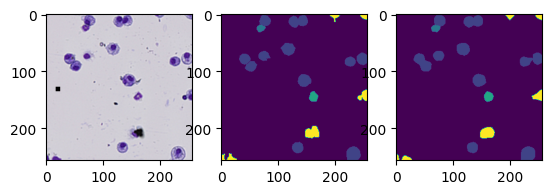

In [25]:
import random
idx = random.randint(0,90)
def visualization_pascalvoc(model, idx):
    model.eval()
    with torch.no_grad():
        x, y = train_dataset.__getitem__(idx) # get x: (C, H , W) , y: (H, W)
#         print(x.shape ,y.shape) # (C, H , W) - > (B, C, H, W) -> model
        x = x.to(device).float().unsqueeze(0) # convert x: (C, H , W) -> (1, C, H, W) vi model need Batch at first
        y = y.to(device).long().unsqueeze(0) # convert x: (C, H , W) -> (1, C, H, W) vi model need Batch at first
        print(y.shape)
        yhat = model(x, y) # input x: (1, C, H, W) and output y: (1, C, H , W)
        print(yhat.shape)
        yhat_mask = yhat.argmax(dim=1) # convert (1, C, H , W) -> (C, H , W)
        print(yhat_mask.shape)
        inv_img_tensor = inverse_norm(x.squeeze()) # x: (1, C, H, W) -> (C, H, W)
#         color_mask_prediction = np.zeros((*yhat_mask.shape,3))
#         for i, color in enumerate(VOC_COLORMAP):
#             color_mask_prediction[yhat_mask.cpu()==i] = np.array(color) # pixel 10(class10) -> [64, 128, 0]

#         color_mask_true = np.zeros((*yhat.shape,3))
#         for i, color in enumerate(VOC_COLORMAP):
#             color_mask_true[yhat.cpu()==i] = np.array(color) # pixel 10(class10) -> [64, 128, 0]
        # draw, x, y, yhat_mask
        plt.subplot(1,3,1)
        plt.imshow(inv_img_tensor.permute(1,2,0).cpu())
        plt.subplot(1,3,2)
        plt.imshow(y.squeeze().cpu())
        plt.subplot(1,3,3)
        plt.imshow(yhat_mask.cpu().permute(1,2,0))
        plt.show()

visualization_pascalvoc(model, idx)